In [3]:
## q1 evaluation of the confusion matrix, f1 score,recall, presision

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

def evaluate_classification():
    data = np.load("fc7_features.npz")
    X = data[data.files[0]]
    y = data[data.files[1]]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    model = KNeighborsClassifier(n_neighbors=3)
    model.fit(X_train, y_train)

    def print_metrics(y_true, y_pred, name):
        print(f"\n{name}")
        print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
        print("Precision:", precision_score(y_true, y_pred, average='weighted'))
        print("Recall   :", recall_score(y_true, y_pred, average='weighted'))
        print("F1-Score :", f1_score(y_true, y_pred, average='weighted'))

    print_metrics(y_train, model.predict(X_train), "Training Data")
    print_metrics(y_test, model.predict(X_test), "Test Data")

evaluate_classification()



Training Data
Confusion Matrix:
 [[  4   0   0   0   0   0   0   0   2   0]
 [  0  10   0   0   0   0   0   1   2   0]
 [  0   0  34   1   0   0   1   0   5   1]
 [  0   1   2  17   0   0   0   0   6   0]
 [  0   0   2   0  13   0   0   1   3   0]
 [  0   0   6   0   0   7   0   0   2   0]
 [  1   1  11   3   0   3  32   0   8   3]
 [  0   1   5   0   2   0   4  15   8   0]
 [  1   2  16   1   0   6   7   3 127   3]
 [  0   1  10   2   1   6   4   1   5  29]]
Precision: 0.6923380393936591
Recall   : 0.6501128668171557
F1-Score : 0.6542466805727556

Test Data
Confusion Matrix:
 [[ 0  1  0  0  0  0  1  0  0  0]
 [ 0  0  3  0  0  0  1  1  0  0]
 [ 1  1 12  1  0  2  1  2  7  1]
 [ 0  0  2  0  0  0  1  0  3  0]
 [ 0  1  1  0  2  0  0  1  4  0]
 [ 0  0  2  1  0  0  0  0  0  0]
 [ 0  0  7  3  0  3  7  3 15  2]
 [ 1  0  0  0  0  1  4  5 14  0]
 [ 1  1  6  3  1  1  3  1 25  2]
 [ 0  0  4  0  1  3  4  1 11  4]]
Precision: 0.3242390542856899
Recall   : 0.2894736842105263
F1-Score : 0.27626547209

In [15]:
#q2 calculate mse,rmse,mape and r2 scores

import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error, r2_score

def regression_evaluation():
    df = pd.read_excel("Lab2 Session Data.xlsx")

    # Remove rows with missing values
    df = df.dropna()

    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]

    X_encoded = pd.get_dummies(X, drop_first=True)

    X_train, X_test, y_train, y_test = train_test_split(
        X_encoded, y, test_size=0.3, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_test - y_pred) / np.maximum(y_test, 1e-8))) * 100
    r2 = r2_score(y_test, y_pred)

    print("MSE :", mse)
    print("RMSE:", rmse)
    print("MAPE:", mape)
    print("R²  :", r2)



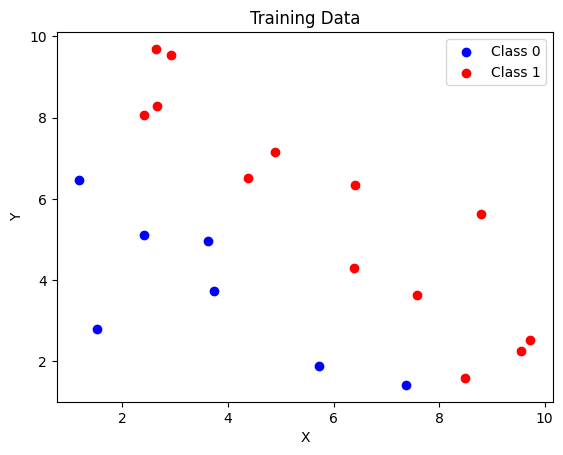

In [9]:
# q3 create a scatter plot from 20 random points

import numpy as np
import matplotlib.pyplot as plt

def generate_training_data():
    np.random.seed(42)

    X = np.random.uniform(1, 10, 20)
    Y = np.random.uniform(1, 10, 20)

    labels = np.where(X + Y > 10, 1, 0)

    plt.scatter(X[labels == 0], Y[labels == 0], color='blue', label='Class 0')
    plt.scatter(X[labels == 1], Y[labels == 1], color='red', label='Class 1')
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.title("Training Data")
    plt.show()

    return np.column_stack((X, Y)), labels

train_X, train_y = generate_training_data()


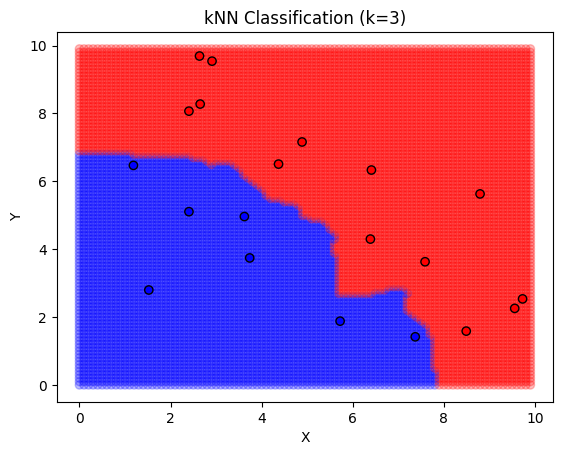

In [10]:
# q4 kNN for k=3

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

def knn_classification_k3(train_X, train_y):
    xx, yy = np.meshgrid(
        np.arange(0, 10, 0.1),
        np.arange(0, 10, 0.1)
    )

    test_points = np.c_[xx.ravel(), yy.ravel()]

    model = KNeighborsClassifier(n_neighbors=3)
    model.fit(train_X, train_y)

    preds = model.predict(test_points)

    plt.scatter(
        test_points[:, 0], test_points[:, 1],
        c=preds, cmap='bwr', alpha=0.25
    )

    plt.scatter(
        train_X[:, 0], train_X[:, 1],
        c=train_y, cmap='bwr', edgecolor='k'
    )

    plt.title("kNN Classification (k=3)")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.show()

knn_classification_k3(train_X, train_y)


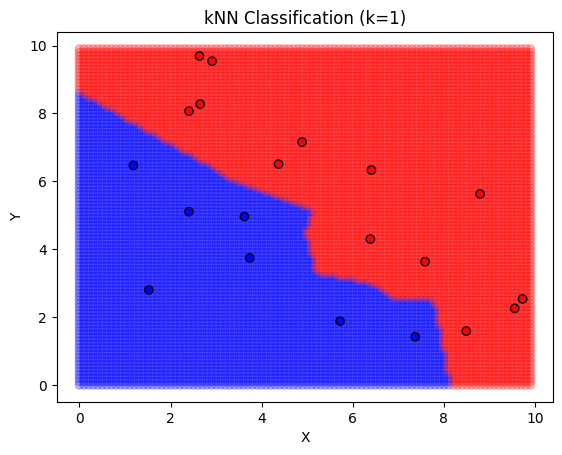

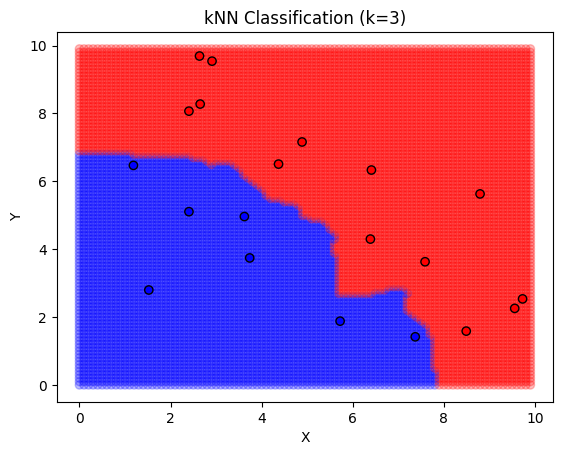

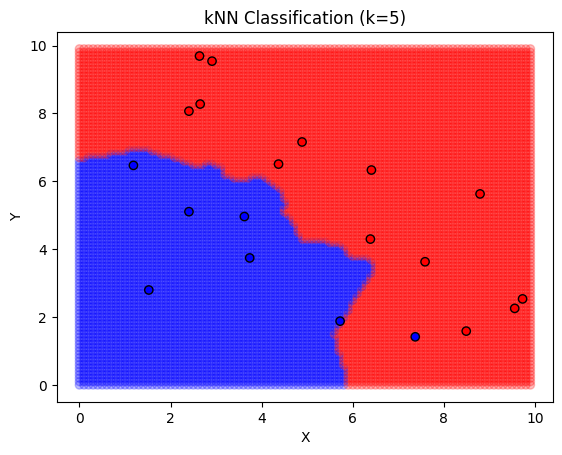

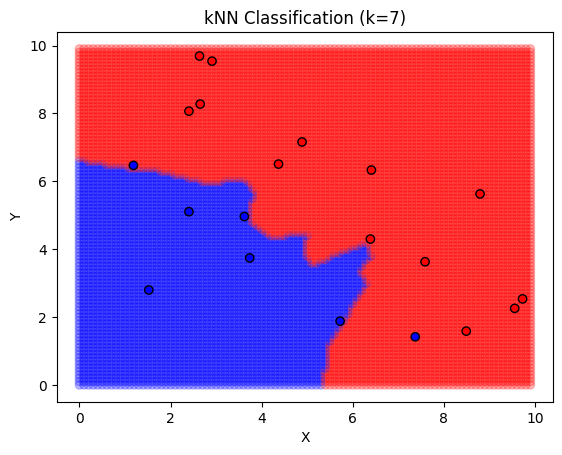

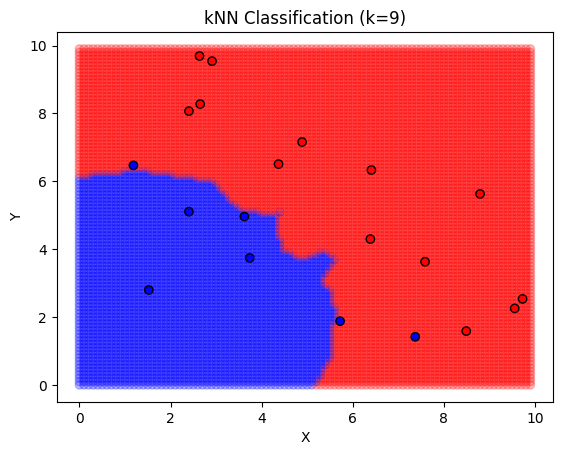

In [11]:
# q5 knn dor diffrent k values

def knn_k_variation(train_X, train_y):
    for k in [1, 3, 5, 7, 9]:
        xx, yy = np.meshgrid(
            np.arange(0, 10, 0.1),
            np.arange(0, 10, 0.1)
        )

        test_points = np.c_[xx.ravel(), yy.ravel()]

        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(train_X, train_y)

        preds = model.predict(test_points)

        plt.figure()
        plt.scatter(
            test_points[:, 0], test_points[:, 1],
            c=preds, cmap='bwr', alpha=0.25
        )
        plt.scatter(
            train_X[:, 0], train_X[:, 1],
            c=train_y, cmap='bwr', edgecolor='k'
        )
        plt.title(f"kNN Classification (k={k})")
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.show()

knn_k_variation(train_X, train_y)


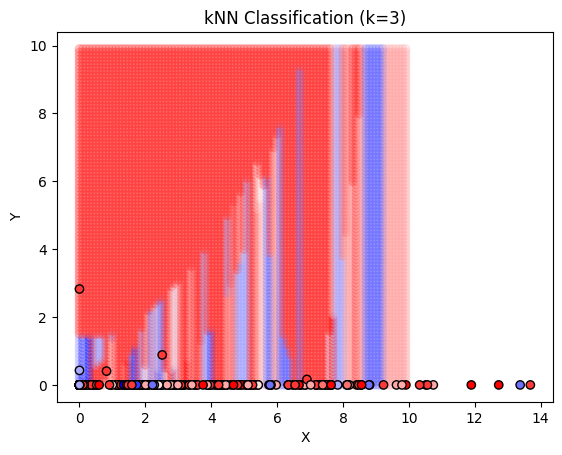

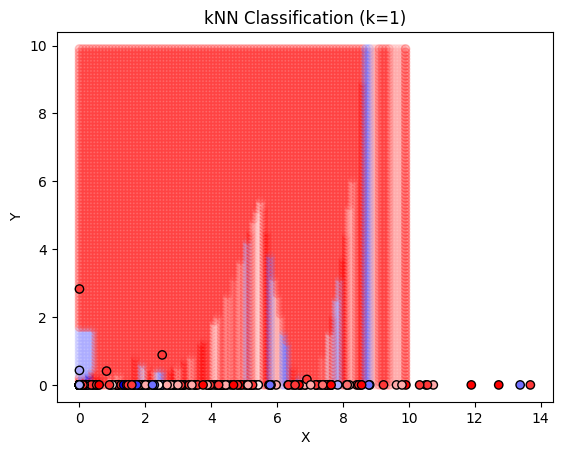

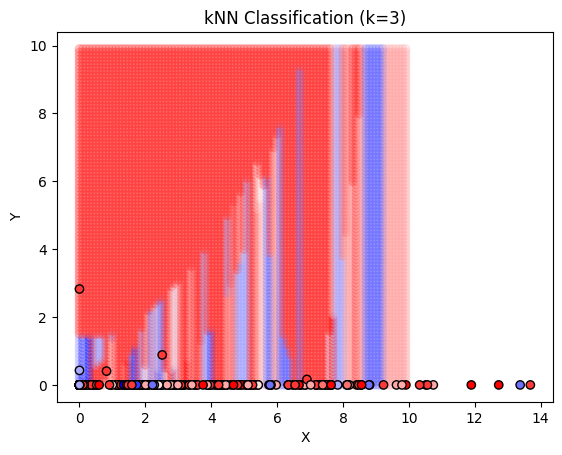

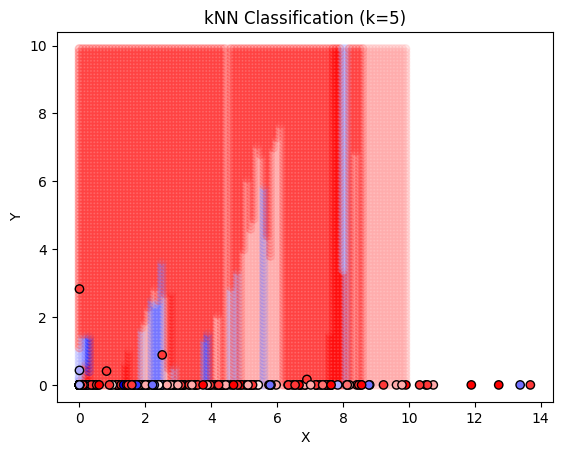

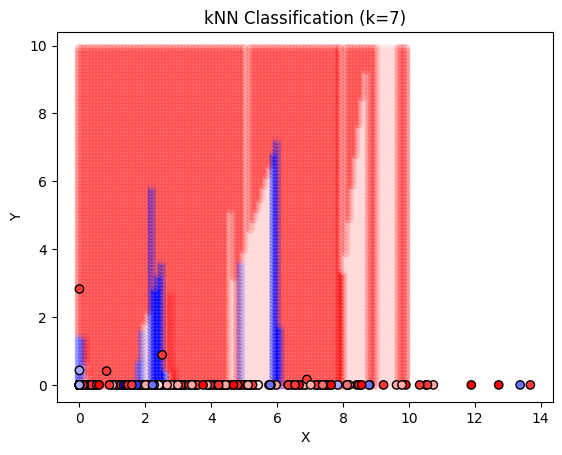

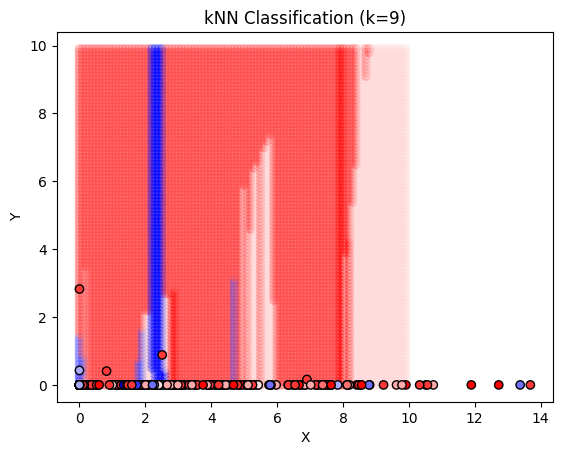

In [17]:
# q6 same as q3,4,5 but for our project data

import numpy as np
from sklearn.model_selection import train_test_split

def project_knn_experiment():
    data = np.load("fc7_features.npz")
    X_full = data[data.files[0]]  
    X = X_full[:, :2]
    y = data[data.files[1]] 

    X_train, _, y_train, _ = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    knn_classification_k3(X_train, y_train)
    knn_k_variation(X_train, y_train)

project_knn_experiment()


In [15]:
#q7 find ideal k value  using GridSearchCV 

import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

def knn_hyperparameter_tuning():
    data = np.load("fc7_features.npz")
    X = data[data.files[0]]
    y = data[data.files[1]]

    param_grid = {'n_neighbors': np.arange(1, 21)}

    grid = GridSearchCV(
        KNeighborsClassifier(),
        param_grid,
        cv=5
    )

    grid.fit(X, y)

    print("Best k value:", grid.best_params_['n_neighbors'])
    print("Best CV Accuracy:", grid.best_score_)

knn_hyperparameter_tuning()


Best k value: 18
Best CV Accuracy: 0.31758530183727035
